In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt
import ast
import seaborn as sns
from urllib.parse import urlparse

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
def merge_ad_article_data(ads_df: pd.DataFrame, articles_df: pd.DataFrame) -> pd.DataFrame:
    """
    Merge ads and articles datasets based on matching image URLs.

    Parameters:
    -----------
    ads_df : DataFrame
        Dataset containing ad information with 'Image_Link' column
    articles_df : DataFrame
        Dataset containing article information with 'Image_Links' column (array/list)

    Returns:
    --------
    DataFrame
        Enhanced ads dataset with article metadata for each ad
    """
    # Create a mapping of image URLs to article metadata
    image_to_article = {}
    for _, article in articles_df.iterrows():
        # Convert string representation of list to actual list if needed
        if isinstance(article['Image_Links'], str):
            image_links = eval(article['Image_Links'])
        else:
            image_links = article['Image_Links']

        # Add article metadata for each image
        for img_url in image_links:
            image_to_article[img_url] = {
                'Published_Date': article['Published_Date'],
                'Sentiment': article['Sentiment'],
                'Tone': article['Tone'],
                'Article_Text': article['Article_Text'],
                'Headline': article['Headline'],
                'Publishing_Agency_Name': article['Publishing_Agency_Name'],
                'Keywords_Tags': article['Keywords_Tags'],
                'Related_Article_Links': article['Related_Article_Links'],
                'Narrative': article['Narrative']
                # Add any other article metadata you need
            }

    # Add article metadata to ads based on matching image URLs
    enhanced_ads = []
    unmatched_ads = []

    for _, ad in ads_df.iterrows():
        ad_data = ad.to_dict()
        if ad['Image_Link'] in image_to_article:
            ad_data.update(image_to_article[ad['Image_Link']])
            enhanced_ads.append(ad_data)
        else:
            unmatched_ads.append(ad['Image_Link'])

    # Create merged dataframe
    merged_df = pd.DataFrame(enhanced_ads)

    # Preprocess dates
    merged_df['Published_Date'] = pd.to_datetime(
        merged_df['Published_Date'],
        format='%d-%m-%Y',
        errors='coerce'
    )

    # Add derived date features
    merged_df['Month'] = merged_df['Published_Date'].dt.month
    merged_df['Month_Name'] = merged_df['Published_Date'].dt.month_name()
    merged_df['Weekday'] = merged_df['Published_Date'].dt.day_name()

    # Print matching statistics
    print(f"Total ads: {len(ads_df)}")
    print(f"Successfully matched ads: {len(enhanced_ads)}")
    print(f"Unmatched ads: {len(unmatched_ads)}")
    if unmatched_ads:
        print("\nSample of unmatched ad images:")
        for url in unmatched_ads[:5]:
            print(f"- {url}")

    return merged_df

In [4]:
datapath_niraj_articles = '/content/drive/MyDrive/NERD: Neutralizing Economic Rewards of Disinformation/Result_artifacts/Articles_Data_Archive/combined_articles_dataset.csv'
datapath_niraj_ads = '/content/drive/MyDrive/NERD: Neutralizing Economic Rewards of Disinformation/Result_artifacts/Ads_Data_Archive/combined_ads_dataset.csv'
datapath_niraj_map = '/content/drive/MyDrive/NERD: Neutralizing Economic Rewards of Disinformation/1 - Data collection/folder_number_to_source_url_mapping.csv'
datapath_niraj_original_file1= '/content/drive/MyDrive/NERD: Neutralizing Economic Rewards of Disinformation/1 - Data collection/ee24_simple.csv'
datapath_niraj_original_file2='/content/drive/MyDrive/NERD: Neutralizing Economic Rewards of Disinformation/1 - Data collection/ee24_simple-with-dates-2024-07-09.csv'

ads_df = pd.read_csv(datapath_niraj_ads)
article_df = pd.read_csv(datapath_niraj_articles)

original_df1 = pd.read_csv(datapath_niraj_original_file1)
original_df2 = pd.read_csv(datapath_niraj_original_file2)

folder_url_map_df = pd.read_csv(datapath_niraj_map)


### Heatmap for company/products vs Media House

In [5]:
combined_original_df = pd.concat([original_df1,original_df2])
mdf = merge_ad_article_data(ads_df,article_df)

Total ads: 1849
Successfully matched ads: 1849
Unmatched ads: 0


In [6]:

# Clean 'ID' column in merged_data to remove '#' character if the value is a string
folder_url_map_df['ID'] = folder_url_map_df['ID'].apply(lambda x: str(x).replace('#', '') if isinstance(x, str) else x)

# Merge the 'mdf' dataframe with 'folder_url_map_df' based on 'Folder_Number' and 'ID' columns
mdf = mdf.merge(folder_url_map_df, left_on='Folder_Number', right_on='ID', how='left')

# Drop 'ID' and 'Observations' columns from the 'mdf' dataframe as they are no longer needed
mdf = mdf.drop(columns=['ID', 'Observations'])

# Filter rows with non-null 'Links' column values
filtered_mdf = mdf.dropna(subset=['Links'])

# Merge 'filtered_mdf' with 'combined_original_df' dataframe based on the 'Links' and 'source_url' columns
merged_data_with_org = filtered_mdf.merge(combined_original_df, left_on='Links', right_on='source_url', how='left')


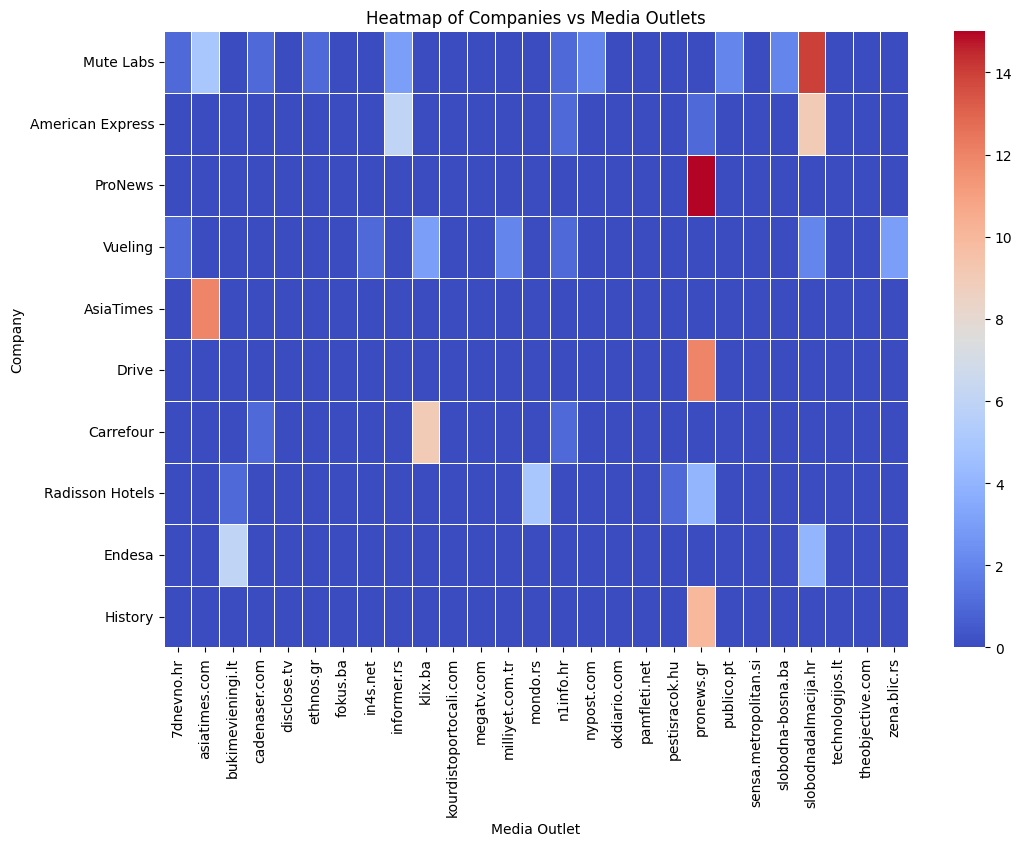

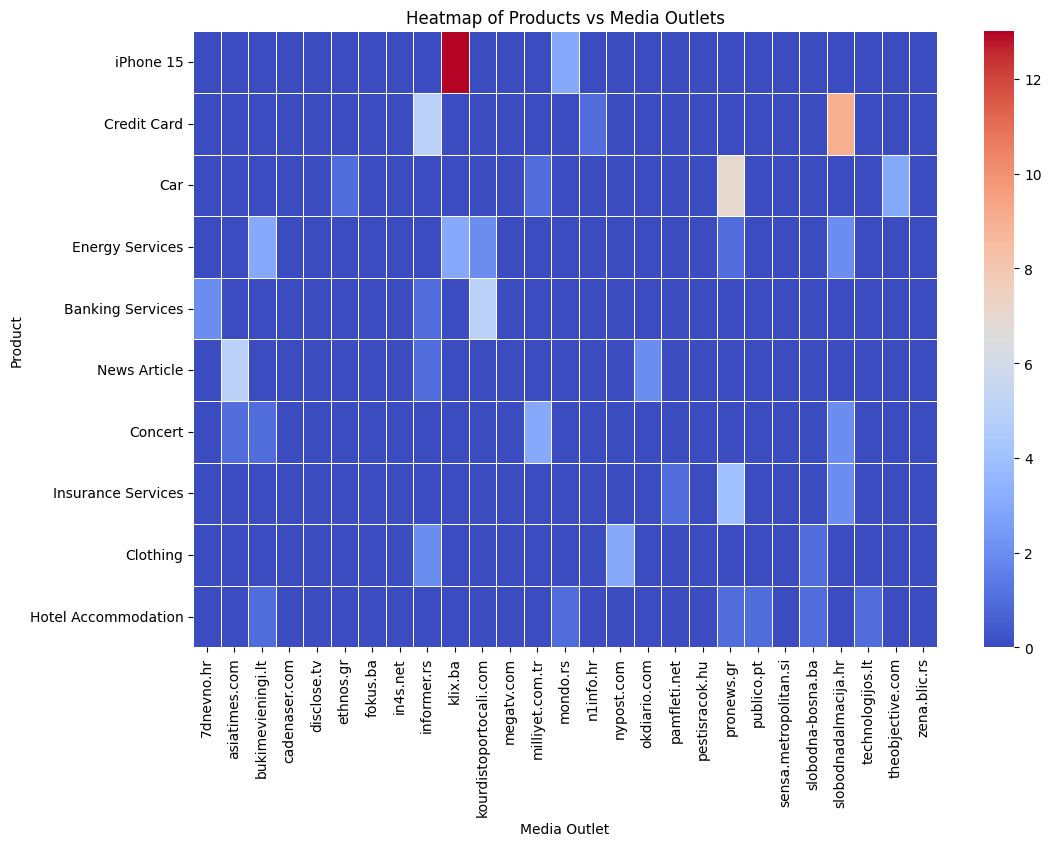

In [ ]:
def extract_domain(url):
    try:
        # Use urlparse to extract the domain (netloc) from the URL
        domain = urlparse(url).netloc
        return domain.replace('www.', '')
    except:
        # Return None if the URL is invalid or an error occurs
        return None# Apply the extract_domain function to 'source_url' and create a new column 'media_outlet'

merged_data_with_org['media_outlet'] = merged_data_with_org['source_url'].apply(extract_domain)

merged_data_with_org =merged_data_with_org[~merged_data_with_org['Company'].isin(['Unknown', 'Not specified'])]
# Count occurrences of each combination of 'Company' and 'media_outlet'
company_media_heatmap_data = (
    merged_data_with_org.groupby(['Company', 'media_outlet'])
    .size()
    .unstack(fill_value=0)
)

# Get the top 10 companies based on the total counts across all media outlets
top_10_companies = company_media_heatmap_data.sum(axis=1).nlargest(10).index

# Filter the heatmap data to only include the top 10 companies
company_media_heatmap_data_top_10 = company_media_heatmap_data.loc[top_10_companies]

# Count occurrences of each combination of 'Product' and 'media_outlet'
product_media_heatmap_data = (
    merged_data_with_org.groupby(['Product', 'media_outlet'])
    .size()
    .unstack(fill_value=0)
)

# Get the top 10 products based on the total counts across all media outlets
top_10_products = product_media_heatmap_data.sum(axis=1).nlargest(10).index

# Filter the heatmap data to only include the top 10 products
product_media_heatmap_data_top_10 = product_media_heatmap_data.loc[top_10_products]

# Plot heatmap for companies vs media outlets
plt.figure(figsize=(12, 8))
sns.heatmap(
    company_media_heatmap_data_top_10,
    cmap='coolwarm',
    annot=False,  # Do not annotate the heatmap cells
    fmt='d',      # Format the values as integers
    linewidths=0.5
)
plt.title('Heatmap of Companies vs Media Outlets')
plt.xlabel('Media Outlet')
plt.ylabel('Company')
plt.show()

# Plot heatmap for products vs media outlets
plt.figure(figsize=(12, 8))
sns.heatmap(
    product_media_heatmap_data_top_10,
    cmap='coolwarm',
    annot=False,  # Do not annotate the heatmap cells
    fmt='d',      # Format the values as integers
    linewidths=0.5
)
plt.title('Heatmap of Products vs Media Outlets')
plt.xlabel('Media Outlet')
plt.ylabel('Product')
plt.show()


In [ ]:
merged_data_with_org = merged_data_with_org[merged_data_with_org['Company'].str.lower() == 'drive']
merged_data_with_org

,Folder_Number,Image_Link,Ad_Name,Product,Company,Ad_Description,Ad_Placement,Published_Date,Sentiment,Tone,...,Unnamed: 0,type,url,headline,euRelation,countryOfOrigin,claimreviewed,source_url,date_published_parsed,media_outlet
185,723,https://drive.google.com/file/d/1xw74FE7b2voBv...,Drive Magazine,Automobile Magazine,Drive,"A magazine focused on automobiles, featuring t...",Top section before the headline,2024-05-05,Neutral,Informative,...,723.0,Debunk,https://www.factchecker.gr/2024/05/06/no-proof...,Misinformation about the existence of 100 Fren...,Direct,GR,The first 100 French soldiers of the 3rd Infan...,https://www.pronews.gr/amyna-asfaleia/enoples-...,NaN,pronews.gr
186,723,https://drive.google.com/file/d/1xw74FE7b2voBv...,Drive Magazine,Automobile Magazine,Drive,"A magazine focused on automobiles, featuring t...",Top section before the headline,2024-05-05,Neutral,Informative,...,853.0,Debunk,https://www.ellinikahoaxes.gr/2024/05/15/estei...,Did France send troops to Ukraine?,Indirect,GR,France officially sent its first troops to Ukr...,https://www.pronews.gr/amyna-asfaleia/enoples-...,2024-05-15 14:35:07.000,pronews.gr
691,139,https://drive.google.com/file/d/1JE35-UHV2kXNN...,Drive Plus Subscription,Weekly car magazine subscription,Drive,A subscription that offers insights and review...,"Top section, banner.",2024-06-04,Neutral,Historical reporting,...,139.0,Debunk,https://www.ellinikahoaxes.gr/2024/03/21/i-gyn...,The woman greeting Hitler is NOT Ursula von de...,Direct,GR,A photo shows Ursula von der Leyen\'s grandmot...,https://www.pronews.gr/kosmos/otan-i-giagia-ti...,NaN,pronews.gr
692,139,https://drive.google.com/file/d/1JE35-UHV2kXNN...,E-Tech Insights,Electric vehicle technology magazine,Drive,A magazine focused on advancements in electric...,"Top section, banner.",2024-06-04,Neutral,Historical reporting,...,139.0,Debunk,https://www.ellinikahoaxes.gr/2024/03/21/i-gyn...,The woman greeting Hitler is NOT Ursula von de...,Direct,GR,A photo shows Ursula von der Leyen\'s grandmot...,https://www.pronews.gr/kosmos/otan-i-giagia-ti...,NaN,pronews.gr
694,139,https://drive.google.com/file/d/1JE35-UHV2kXNN...,Drive Classic Magazine,Classic cars magazine,Drive,A magazine dedicated to classic car enthusiast...,"Top section, banner.",2024-06-04,Neutral,Historical reporting,...,139.0,Debunk,https://www.ellinikahoaxes.gr/2024/03/21/i-gyn...,The woman greeting Hitler is NOT Ursula von de...,Direct,GR,A photo shows Ursula von der Leyen\'s grandmot...,https://www.pronews.gr/kosmos/otan-i-giagia-ti...,NaN,pronews.gr
811,214,https://drive.google.com/file/d/1nMkpyETF1f4fU...,Drive Magazine,Automotive and Technology Magazine,Drive,A magazine focusing on automotive news and tec...,"Top section, before the headline",2024-03-16,Negative,Urgent,...,214.0,Debunk,https://www.ellinikahoaxes.gr/2024/04/03/estei...,Did Emmanuel Macron send troops to Ukraine?,Indirect,GR,The first French soldiers sent by Emmanuel Mac...,https://www.pronews.gr/amyna-asfaleia/enoples-...,NaN,pronews.gr
821,130,https://drive.google.com/file/d/14tknxhhLJmVxI...,Drive Magazine Subscription,Automobile Magazine Subscription,Drive,Subscribe to Drive Magazine for the latest new...,Top banner,2024-03-09,Negative,Critical,...,130.0,Debunk,https://www.ellinikahoaxes.gr/2024/03/19/parap...,Does a recent photo depict an open prayer of M...,Indirect,GR,Photo shows a recent group prayer of Muslims a...,https://www.pronews.gr/koinonia/xiliades-paran...,NaN,pronews.gr
1032,130,https://drive.google.com/file/d/1t21-LP9pt-CA2...,Drive E-Tech,Automotive magazine,Drive,Promotes the automotive magazine Drive focusin...,Top section near the headline,2024-03-09,Negative,Fear-mongering,...,130.0,Debunk,https://www.ellinikahoaxes.gr/2024/03/19/parap...,Does a recent photo depict an open prayer of M...,Indirect,GR,Photo shows a recent group prayer of Muslims a...,https://www.pronews.gr/koinonia/xiliades-paran...,NaN,pronews.gr
1040,139,https://drive.google.com/file/d/1sFYsV-zFXiQHJ...,Dr

### Debunked Fake news per Country

In [7]:
combined_original_df = combined_original_df.drop(columns = ['Unnamed: 0'])

In [17]:
# Mapping dictionary
country_mapping = {
    'AL': 'Albania',
    'AT': 'Austria',
    'BA': 'Bosnia and Herzegovina',
    'BE': 'Belgium',
    'BG': 'Bulgaria',
    'CH': 'Switzerland',
    'CZ': 'Czech Republic',
    'DE': 'Germany',
    'DK': 'Denmark',
    'ES': 'Spain'
}
combined_original_df['countryOfOrigin'] = combined_original_df['countryOfOrigin'].map(country_mapping)

In [ ]:
def plot_debunks_per_country(dataframe, type_column='type', country_column='countryOfOrigin', plot_title='Debunks Per Country'):
    """
    Plots a bar chart of the number of 'Debunk' entries per country.

    Parameters:
        dataframe (pd.DataFrame): The dataframe containing the data.
        type_column (str): The name of the column indicating the type (e.g., 'Debunk').
        country_column (str): The name of the column indicating the country.
        plot_title (str): The title for the plot.
    """
    # Filter and aggregate the data
    debunk_per_country = (
        dataframe[dataframe[type_column] == 'Debunk']
        .groupby([country_column])
        .size()
        .reset_index(name='count')
    )

    # Plot the bar chart
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=country_column,
        y='count',
        data=debunk_per_country,
        palette='viridis'
    )

    # Add labels and title
    plt.xlabel('Country of Origin', fontsize=12)
    plt.ylabel('Number of Debunks', fontsize=12)
    plt.title(plot_title, fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Show the plot
    plt.show()


In [ ]:
def plot_most_frequent_domains(dataframe, url_column='source_url', top_n=10, plot_title='Most Frequent Domains'):
    """
    Plots a bar chart of the most frequent domains from the provided URL column.

    Parameters:
        dataframe (pd.DataFrame): The dataframe containing the data.
        url_column (str): The column name containing the URLs.
        top_n (int): The number of top domains to display.
        plot_title (str): The title for the plot.
    """

    # Get the most frequent domains
    most_frequent_domains = dataframe['domain'].value_counts().head(top_n).reset_index()
    most_frequent_domains.columns = ['domain', 'count']

    # Plot the bar chart
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x='domain',
        y='count',
        data=most_frequent_domains,
        palette='viridis'
    )

    # Add labels and title
    plt.xlabel('Domain', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title(plot_title, fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Show the plot
    plt.show()


In [ ]:
def plot_misinformer_vs_factchecker_heatmap(dataframe, url_column='url', source_url_column='source_url', top_n=10, plot_title='Heatmap of Misinformer vs Factchecker'):
    """
    Plots a heatmap showing the relationship between the top misinformers and factcheckers.

    Parameters:
        dataframe (pd.DataFrame): The dataframe containing the data.
        url_column (str): The column name containing the factchecker URLs.
        source_url_column (str): The column name containing the source (misinformation) URLs.
        top_n (int): The number of top misinformers and factcheckers to display.
        plot_title (str): The title for the plot.
    """

    # Compute heatmap data
    misinformer_vs_factchecker_heatmap_data = (
        dataframe.groupby(['source domain', 'factcheck domain'])
        .size()
        .unstack(fill_value=0)
    )

    # Get top N misinformers
    top_n_misinformer = misinformer_vs_factchecker_heatmap_data.sum(axis=1).nlargest(top_n).index

    # Get top N factcheckers
    top_n_factchecker = misinformer_vs_factchecker_heatmap_data.sum(axis=0).nlargest(top_n).index

    # Filter heatmap data for top N misinformers and top N factcheckers
    top_n_misinformer_factchecker_heatmap_data = misinformer_vs_factchecker_heatmap_data.loc[
        top_n_misinformer, top_n_factchecker
    ]

    # Plot the heatmap
    plt.figure(figsize=(12, 8))  # Adjust size as needed
    sns.heatmap(
        top_n_misinformer_factchecker_heatmap_data,
        cmap='coolwarm',
        annot=False,  # Do not annotate the heatmap cells
        fmt='d',      # Format the values as integers
        linewidths=0.5
    )
    plt.title(plot_title, fontsize=16)
    plt.xlabel('Factchecker Domains', fontsize=12)
    plt.ylabel('Misinformer Domains', fontsize=12)
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_misinformer_vs_debunk_per_country_heatmap(dataframe, type_column='type',
                                                   country_column='countryOfOrigin',
                                                   domain_column='factcheck domain',
                                                   plot_title='Heatmap of Misinformer vs Debunk Per Country',
                                                   top_n=None):
    """
    Plots a heatmap of misinformers vs debunks per country based on the specified dataframe and columns.

    Parameters:
        dataframe (pd.DataFrame): The dataframe containing the data.
        type_column (str): The column name containing the type (e.g., 'Debunk').
        country_column (str): The column name indicating the country of origin.
        domain_column (str): The column name for factcheck domains.
        plot_title (str): The title for the plot.
        top_n (int, optional): The number of top countries or domains to display (None for all).
    """
    # Filter data based on the type column (e.g., 'Debunk')
    filtered_df = dataframe[dataframe[type_column] == 'Debunk']

    # Group by factcheck domain and country, and count occurrences
    misinformer_vs_debunk_heatmap_data = (
        filtered_df.groupby([domain_column, country_column])
        .size()
        .unstack(fill_value=0)
    )

    # If top_n is specified, filter the data to show top_n countries or domains
    if top_n:
        top_countries = misinformer_vs_debunk_heatmap_data.sum(axis=1).nlargest(top_n).index
        top_domains = misinformer_vs_debunk_heatmap_data.sum(axis=0).nlargest(top_n).index
        misinformer_vs_debunk_heatmap_data = misinformer_vs_debunk_heatmap_data.loc[top_domains, top_countries]

    # Set figure size for the heatmap
    plt.figure(figsize=(12, 8))

    # Create the heatmap
    sns.heatmap(
        misinformer_vs_debunk_heatmap_data,
        cmap='coolwarm',
        annot=False,  # Do not annotate the heatmap cells
        fmt='d',      # Format the values as integers
        linewidths=0.5
    )

    # Add title and labels
    plt.title(plot_title, fontsize=16)
    plt.xlabel('Factchecker Domains', fontsize=12)
    plt.ylabel('Country of Origin', fontsize=12)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=90)

    # Adjust layout to prevent clipping
    plt.tight_layout()

    # Display the plot
    plt.show()


In [ ]:

    # Extract domain from URLs
    combined_original_df['factcheck domain'] = combined_original_df['url'].apply(extract_domain)
    combined_original_df['source domain'] = combined_original_df['source_url'].apply(extract_domain)

### Analysis for Entire Dataset

<ipython-input-21-535483f8049c>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


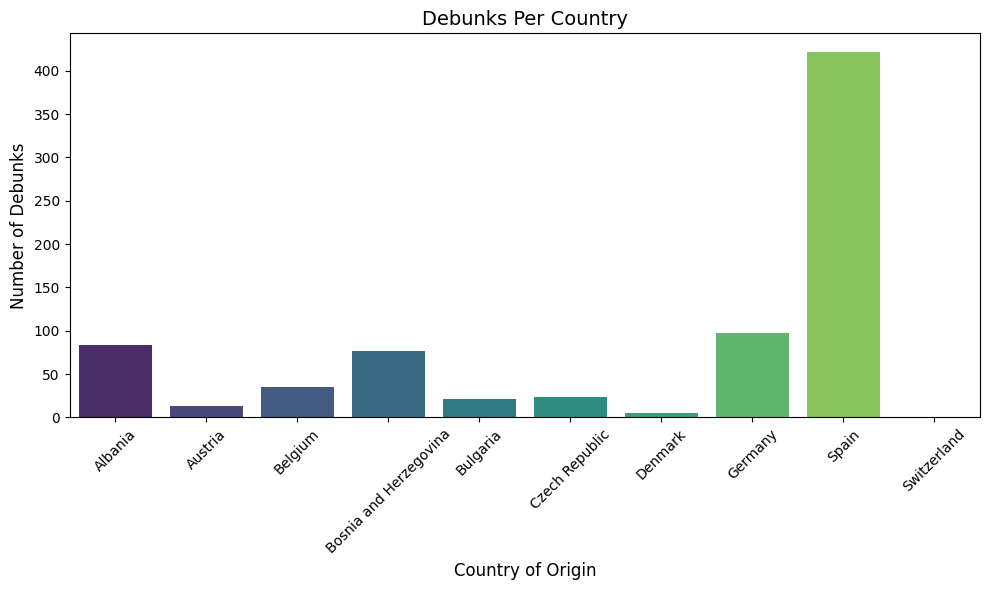

<ipython-input-22-67c04f5491e9>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


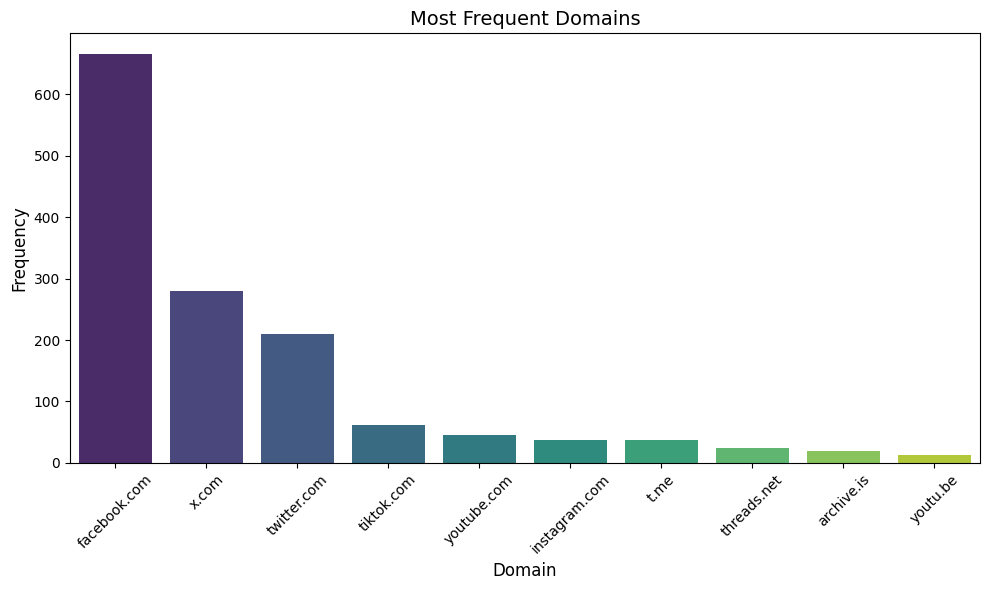

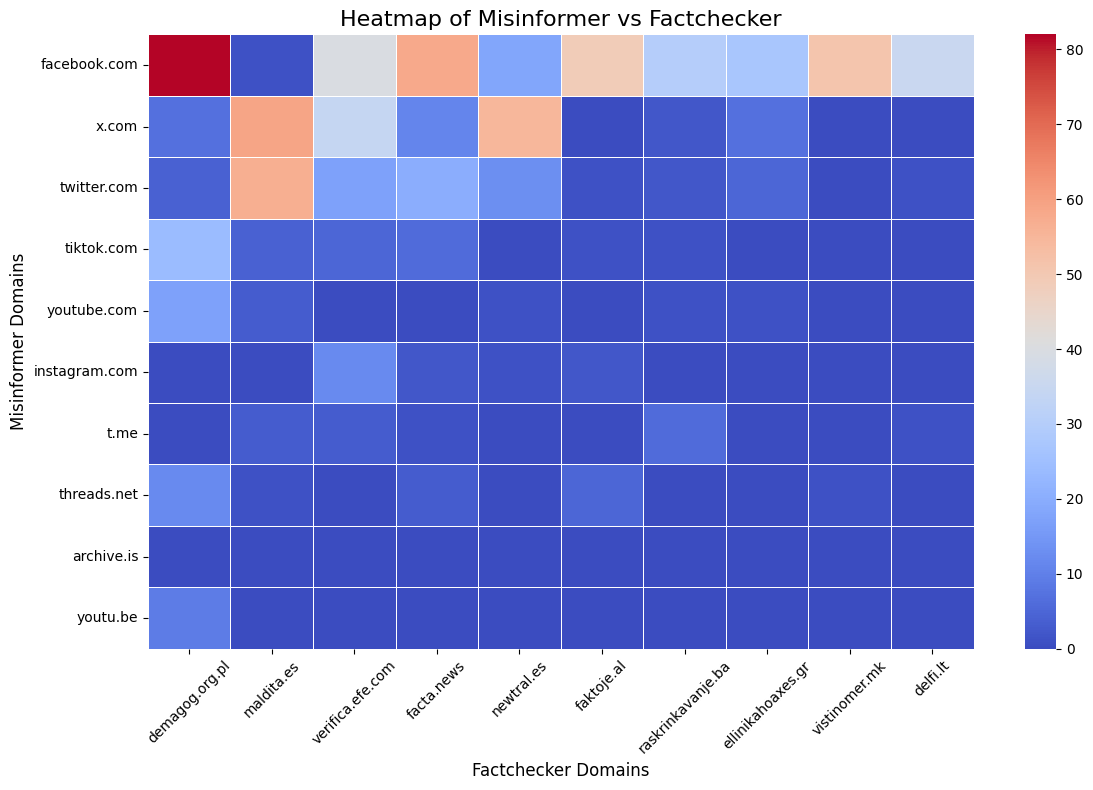

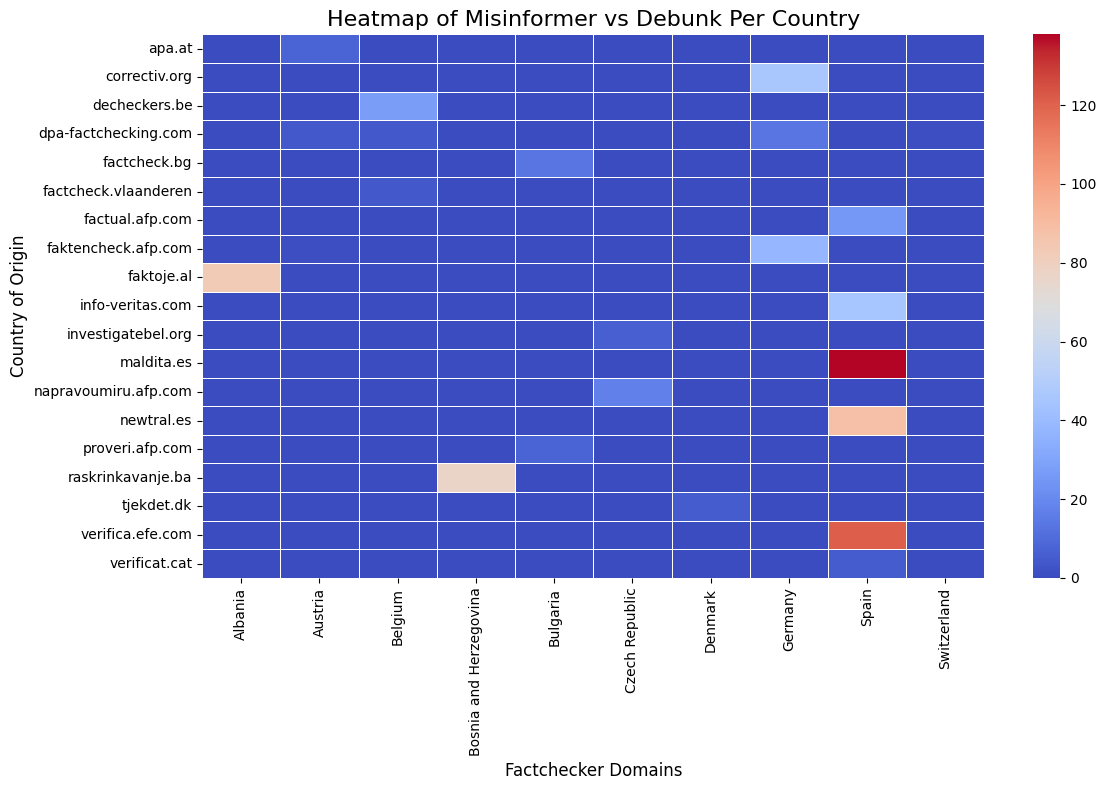

In [ ]:
plot_debunks_per_country(combined_original_df)
plot_most_frequent_domains(combined_original_df)
plot_misinformer_vs_factchecker_heatmap(combined_original_df)
plot_misinformer_vs_debunk_per_country_heatmap(combined_original_df)

### Analysis of the Dataset for Direct Relationships in the European Union

<ipython-input-21-535483f8049c>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


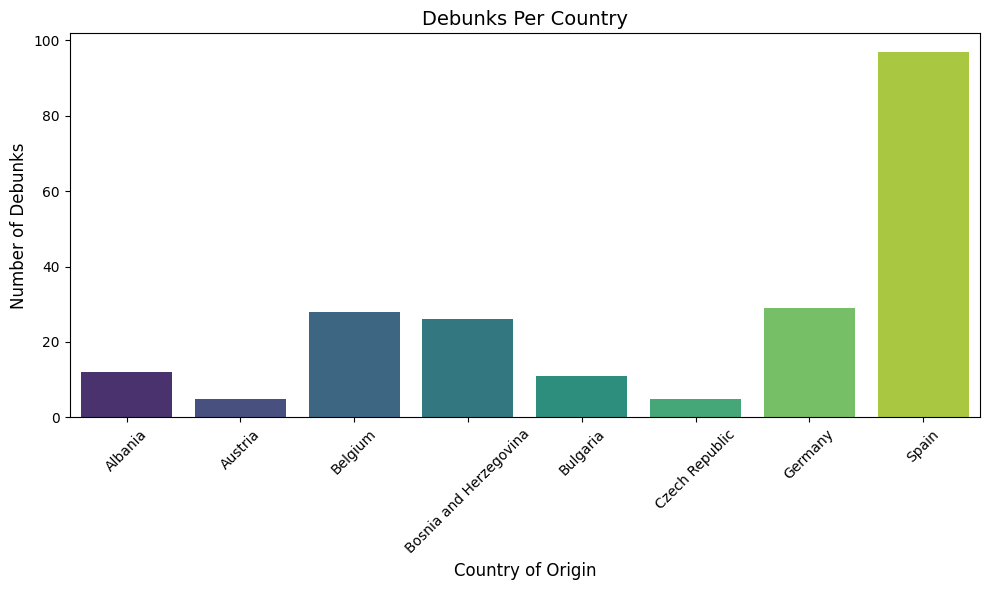

<ipython-input-22-67c04f5491e9>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


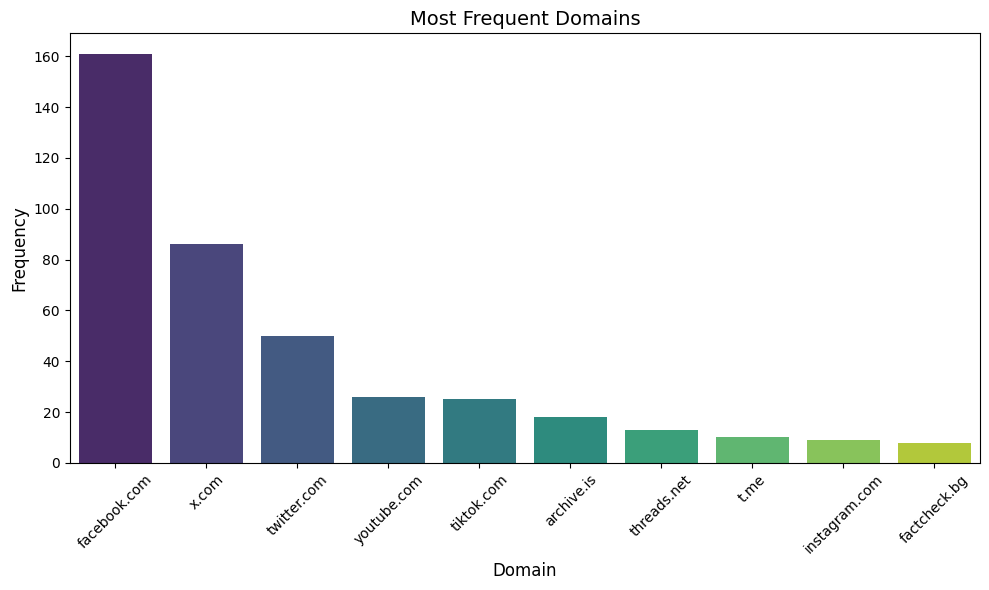

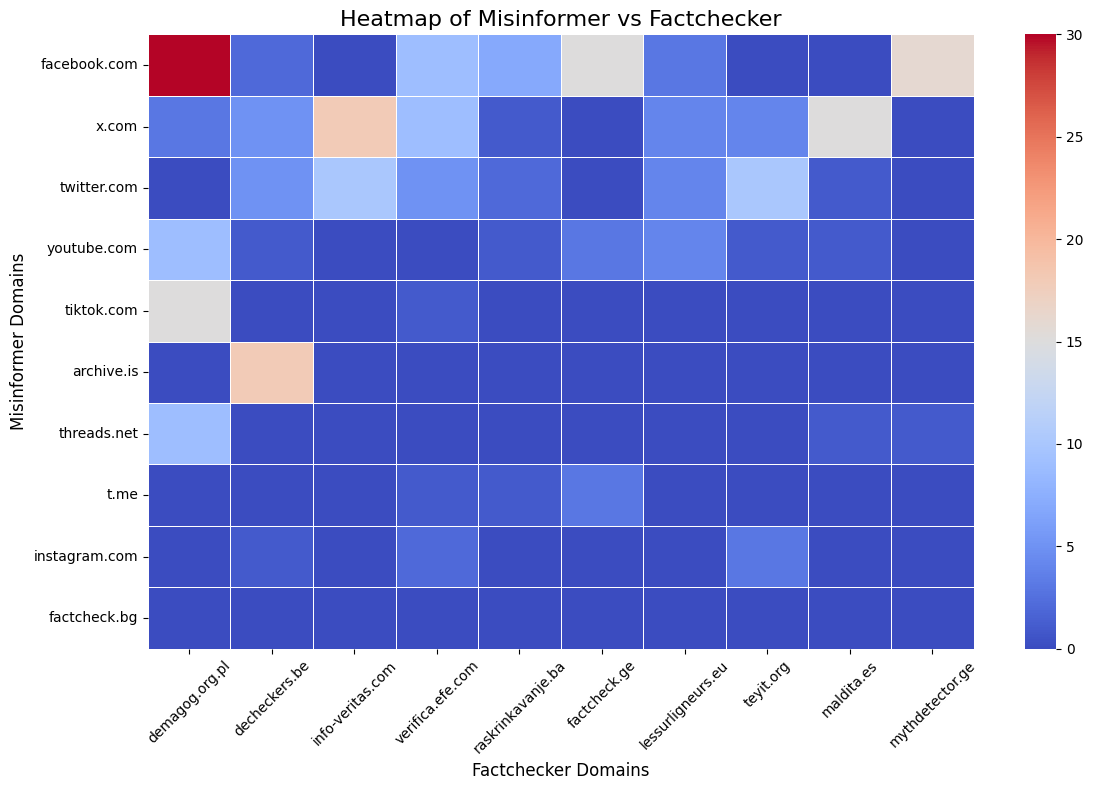

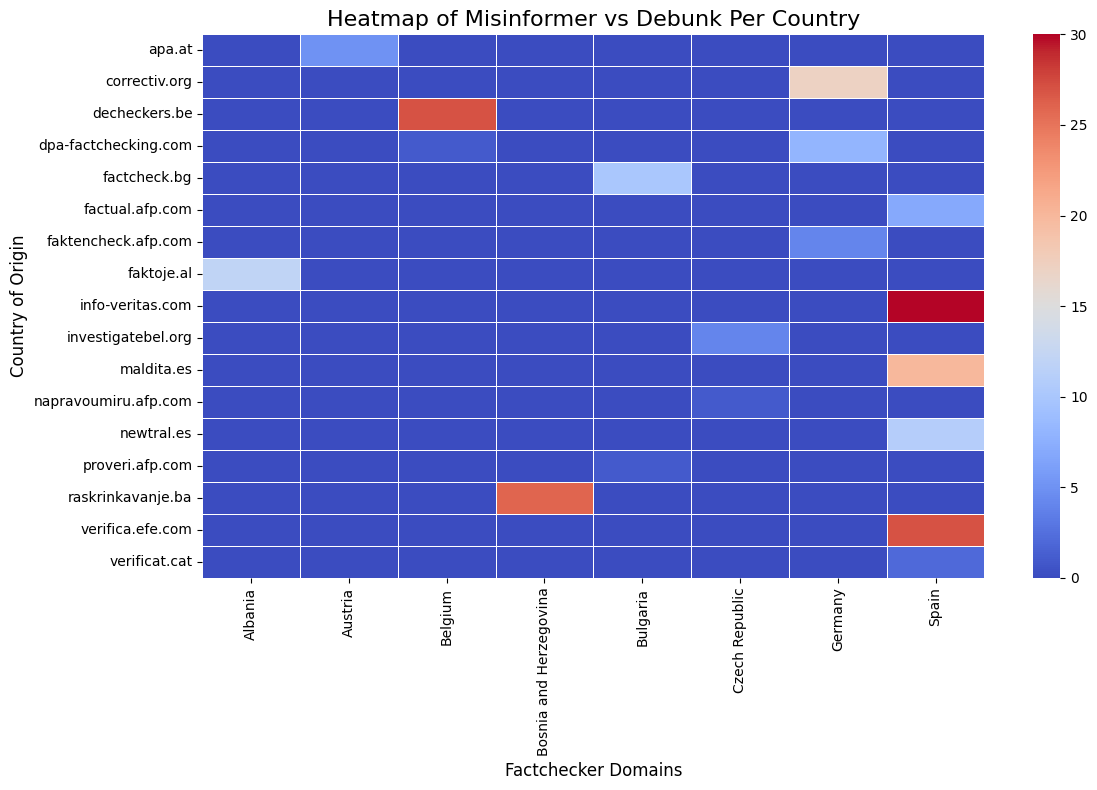

In [ ]:
direct_eurelation = combined_original_df[combined_original_df['euRelation']== 'Direct']
plot_debunks_per_country(direct_eurelation)
plot_most_frequent_domains(direct_eurelation)
plot_misinformer_vs_factchecker_heatmap(direct_eurelation)
plot_misinformer_vs_debunk_per_country_heatmap(direct_eurelation)

### Analysis of the Dataset for Indirect Relationships in the European Union

<ipython-input-21-535483f8049c>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


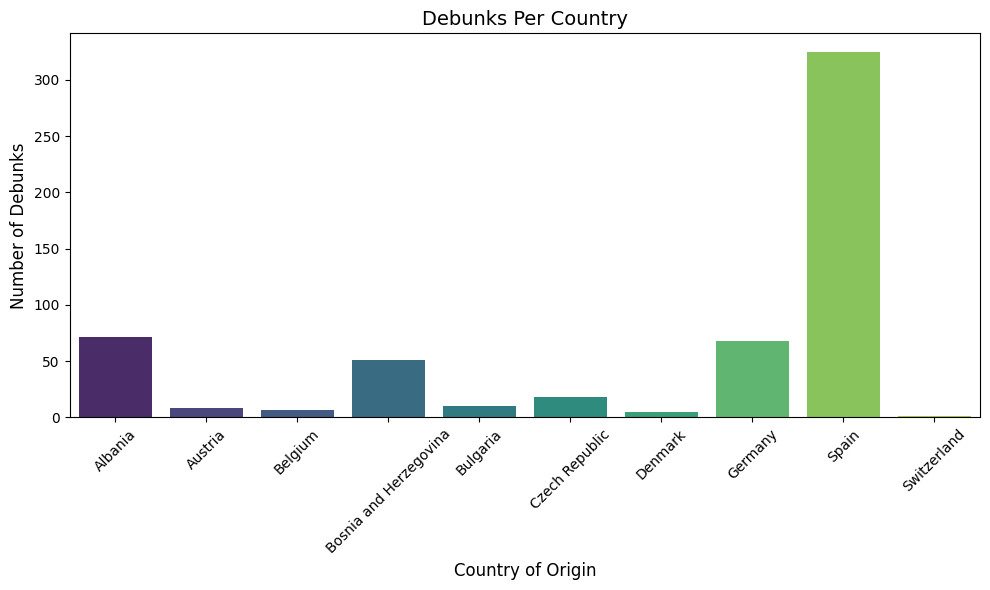

<ipython-input-22-67c04f5491e9>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


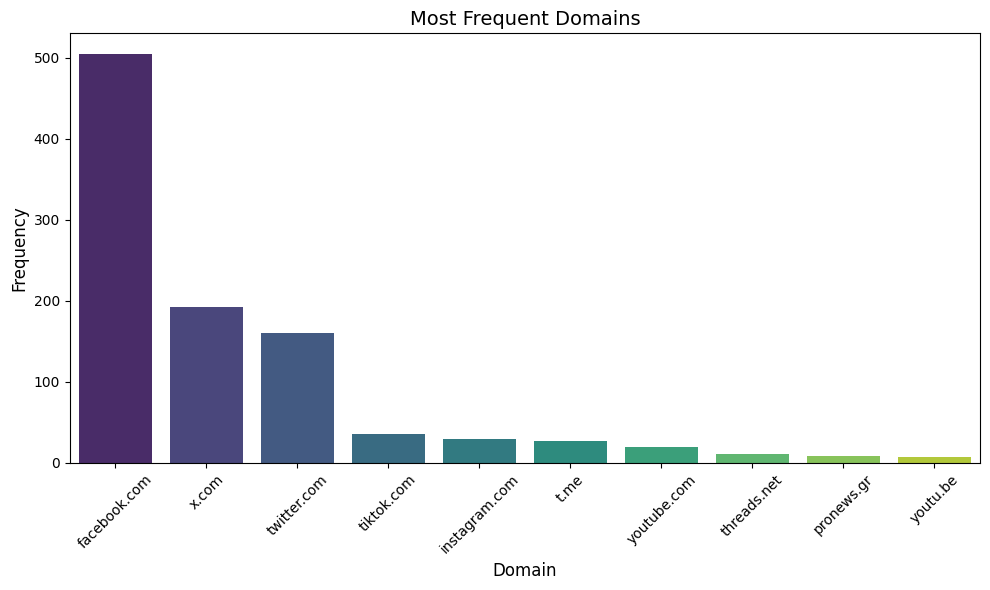

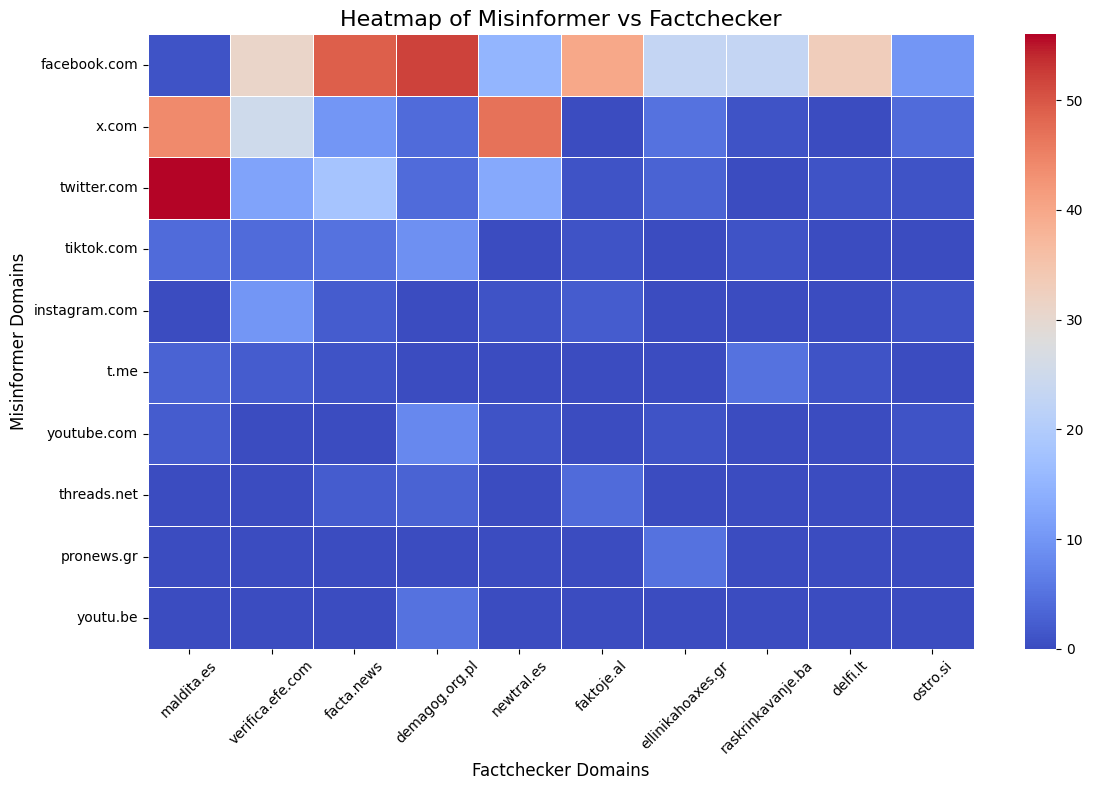

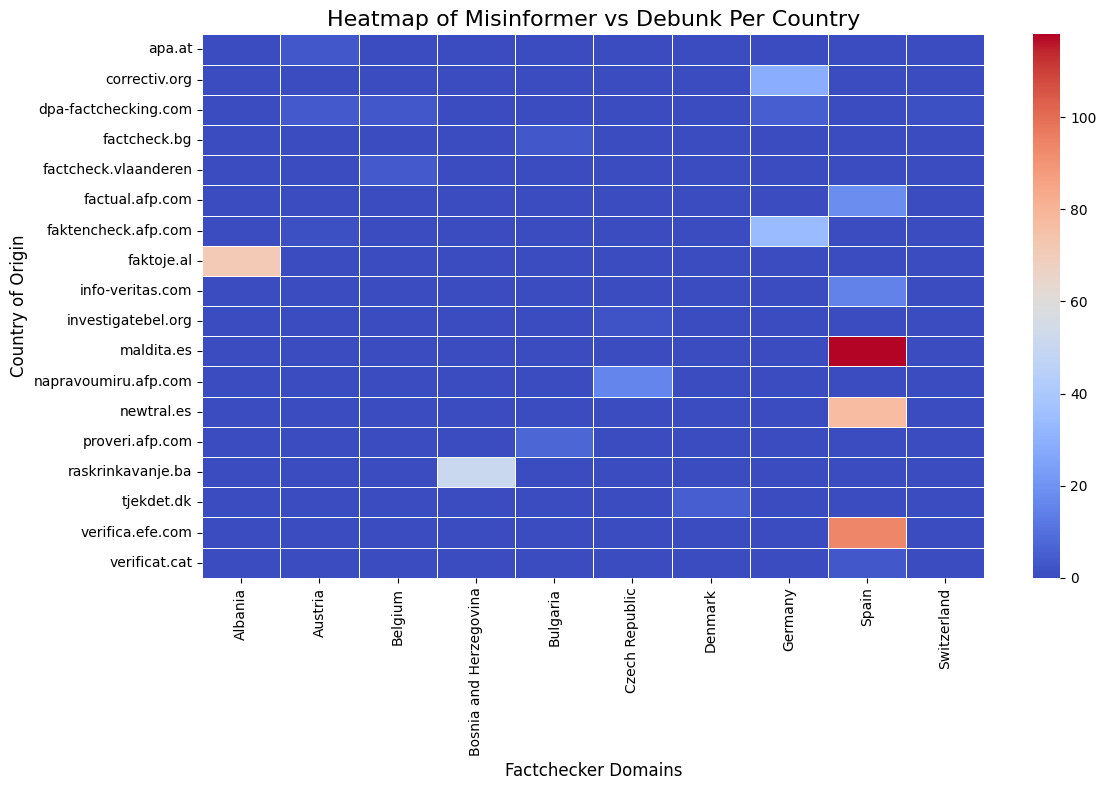

In [ ]:
indirect_eurelation = combined_original_df[combined_original_df['euRelation']== 'Indirect']
plot_debunks_per_country(indirect_eurelation)
plot_most_frequent_domains(indirect_eurelation)
plot_misinformer_vs_factchecker_heatmap(indirect_eurelation)
plot_misinformer_vs_debunk_per_country_heatmap(indirect_eurelation)

In [20]:
# Ensure 'Company' column has no NaN or non-string types before applying len()


,Folder_Number,Image_Link,Ad_Name,Product,Company,Ad_Description,Ad_Placement,Published_Date,Sentiment,Tone,...,Links,Unnamed: 0,type,url,headline,euRelation,countryOfOrigin,claimreviewed,source_url,date_published_parsed
0,567,https://drive.google.com/file/d/1hBdhtHJdH3RMB...,AirEuropa,Flight Services,Air Europa,"Spain and Europe from 17 EUR, America from 246...",sidebar,2024-01-30,Negative,Warning,...,https://informer.rs/planeta/vesti/870728/pocel...,567.0,Debunk,https://raskrinkavanje.ba/analiza/informerovo-...,Informer's scaring of readers by the Third Wor...,Direct,Bosnia and Herzegovina,Europe declares Putin's war to extermination! ...,https://informer.rs/planeta/vesti/870728/pocel...,NaN
1,567,https://drive.google.com/file/d/1hBdhtHJdH3RMB...,El Corte Inglés,Electronics and IT accessories,El Corte Inglés,IT store offering various tech products,inline,2024-01-30,Negative,Warning,...,https://informer.rs/planeta/vesti/870728/pocel...,567.0,Debunk,https://raskrinkavanje.ba/analiza/informerovo-...,Informer's scaring of readers by the Third Wor...,Direct,Bosnia and Herzegovina,Europe declares Putin's war to extermination! ...,https://informer.rs/planeta/vesti/870728/pocel...,NaN
2,567,https://drive.google.com/file/d/13dojG4THjVX9r...,American Express,Credit Card,American Express,Get 800€ for your restaurant expenses,Sidebar,2024-01-30,Negative,Warning,...,https://informer.rs/planeta/vesti/870728/pocel...,567.0,Debunk,https://raskrinkavanje.ba/analiza/informerovo-...,Informer's scaring of readers by the Third Wor...,Direct,Bosnia and Herzegovina,Europe declares Putin's war to extermination! ...,https://informer.rs/planeta/vesti/870728/pocel...,NaN
3,567,https://drive.google.com/file/d/1XbPaEeQVV5FmL...,Renault Clio E-Tech Full Hybrid,Hybrid Car,Renault,Introducing the new Renault Clio with full hyb...,sidebar,2024-01-30,Negative,Warning,...,https://informer.rs/planeta/vesti/870728/pocel...,567.0,Debunk,https://raskrinkavanje.ba/analiza/informerovo-...,Informer's scaring of readers by the Third Wor...,Direct,Bosnia and Herzegovina,Europe declares Putin's war to extermination! ...,https://informer.rs/planeta/vesti/870728/pocel...,NaN
4,567,https://drive.google.com/file/d/1XbPaEeQVV5FmL...,American Express Card Offer,Credit Card,American Express,Get 800€* to spend in restaurants with the Ame...,banner,2024-01-30,Negative,Warning,...,https://informer.rs/planeta/vesti/870728/pocel...,567.0,Debunk,https://raskrinkavanje.ba/analiza/informerovo-...,Informer's scaring of readers by the Third Wor...,Direct,Bosnia and Herzegovina,Europe declares Putin's war to extermination! ...,https://informer.rs/planeta/vesti/870728/pocel...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1496,S08,https://drive.google.com/file/d/1APqJzgYxPWF-O...,KNAUS Offers,Recreational Vehicle Offers,KNAUS,Take advantage of exclusive discounts! Only un...,Bottom section,NaT,NaN,NaN,...,www.dondiario.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1497,S08,https://drive.google.com/file/d/1Mpf4FDSqRVMql...,Barceló,Travel Services,Barceló.com,Live the summer at your own rhythm with discou...,Banner in the middle of the page,NaT,NaN,NaN,...,www.dondiario.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1498,S08,https://drive.google.com/file/d/1Mpf4FDSqRVMql...,Barceló,Pilates Classes,Barceló.com,Start wall Pilates now with discounts up to 30%.,Bottom section of the page,NaT,NaN,NaN,...,www.dondiario.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1500,S08,https://drive.google.com/file/d/1u1JQlJpdzavEY...,Inicia Pilates de Pared,Pilates Classes,Barcelo,Introduction to wall Pilates classes.,Sidebar,NaT,NaN,NaN,...,www.dondiario.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
# Group data to get the most frequent companies per country
most_frequent_companies_per_country = (
    merged_data_with_org[merged_data_with_org['type'] == 'Debunk']
    .groupby(['countryOfOrigin', 'Company'])
    .size()
    .reset_index(name='count')
)

# Top 10 companies per country
top_companies_per_country = (
    most_frequent_companies_per_country
    .sort_values(['countryOfOrigin', 'count'], ascending=[True, False])
    .groupby('countryOfOrigin')
    .head(10)
)


# Group data to get the most frequent products per country
most_frequent_products_per_country = (
    merged_data_with_org[merged_data_with_org['type'] == 'Debunk']
    .groupby(['countryOfOrigin', 'Product'])
    .size()
    .reset_index(name='count')
)

# Top 10 products per country
top_products_per_country = (
    most_frequent_products_per_country
    .sort_values(['countryOfOrigin', 'count'], ascending=[True, False])
    .groupby('countryOfOrigin')
    .head(10)
)

In [34]:
most_frequent_companies_per_country['countryOfOrigin'].unique()

array(['Albania', 'Bosnia and Herzegovina', 'Spain'], dtype=object)

In [40]:
# Plot top companies per country
def plot_top_companies(dataframe):

    mdf_filt = dataframe[(dataframe.Company.notna()) &
                                (dataframe.Company.astype(str).apply(len) > 3)]

    # Filter out invalid values in a single step
    invalid_values = ['[Unknown]', '[Not specified]', 'Unknown', 'Not specified']
    mdf_filt = mdf_filt[~mdf_filt.Company.isin(invalid_values)]
    # Group data to get the most frequent companies per country
    most_frequent_companies_per_country = (
        mdf_filt[mdf_filt['type'] == 'Debunk']
        .groupby(['countryOfOrigin', 'Company'])
        .size()
        .reset_index(name='count')
    )

    # Top 10 companies per country
    top_companies_per_country = (
        most_frequent_companies_per_country
        .sort_values(['countryOfOrigin', 'count'], ascending=[True, False])
        .groupby('countryOfOrigin')
        .head(10)
    )

    countries = top_companies_per_country['countryOfOrigin'].unique()

    # Set up the figure
    plt.figure(figsize=(15, 10))
    for i, country in enumerate(countries):
        plt.subplot(len(countries), 1, i + 1)
        country_data = top_companies_per_country[top_companies_per_country['countryOfOrigin'] == country]
        sns.barplot(
            x='count', y='Company',
            data=country_data,
            palette='viridis'
        )
        plt.title(f"Top Companies Advertised in {country}")
        plt.xlabel('Frequency')
        plt.ylabel('Company')

    plt.tight_layout()
    plt.show()



In [41]:
# Plot top products per country
def plot_top_products(dataframe):

    mdf_filt = dataframe[(dataframe.Product.notna()) & (dataframe.Product.astype(str).apply(len) > 3)]
    mdf_filt = mdf_filt[~mdf_filt.Product.isin(['Unknown', 'Not specified'])]

    # Group data to get the most frequent products per country
    most_frequent_products_per_country = (
        mdf_filt[mdf_filt['type'] == 'Debunk']
        .groupby(['countryOfOrigin', 'Product'])
        .size()
        .reset_index(name='count')
    )

    # Top 10 products per country
    top_products_per_country = (
        most_frequent_products_per_country
        .sort_values(['countryOfOrigin', 'count'], ascending=[True, False])
        .groupby('countryOfOrigin')
        .head(10)
    )
    countries = top_products_per_country['countryOfOrigin'].unique()

    # Set up the figure
    plt.figure(figsize=(15, 10))
    for i, country in enumerate(countries):
        plt.subplot(len(countries), 1, i + 1)
        country_data = top_products_per_country[top_products_per_country['countryOfOrigin'] == country]
        sns.barplot(
            x='count', y='Product',
            data=country_data,
            palette='mako'
        )
        plt.title(f"Top Products Advertised in {country}")
        plt.xlabel('Frequency')
        plt.ylabel('Product')

    plt.tight_layout()
    plt.show()

### Most Frequent Companies/Products per Country for entire dataset

<ipython-input-35-a21fd3b660f7>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-35-a21fd3b660f7>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-35-a21fd3b660f7>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


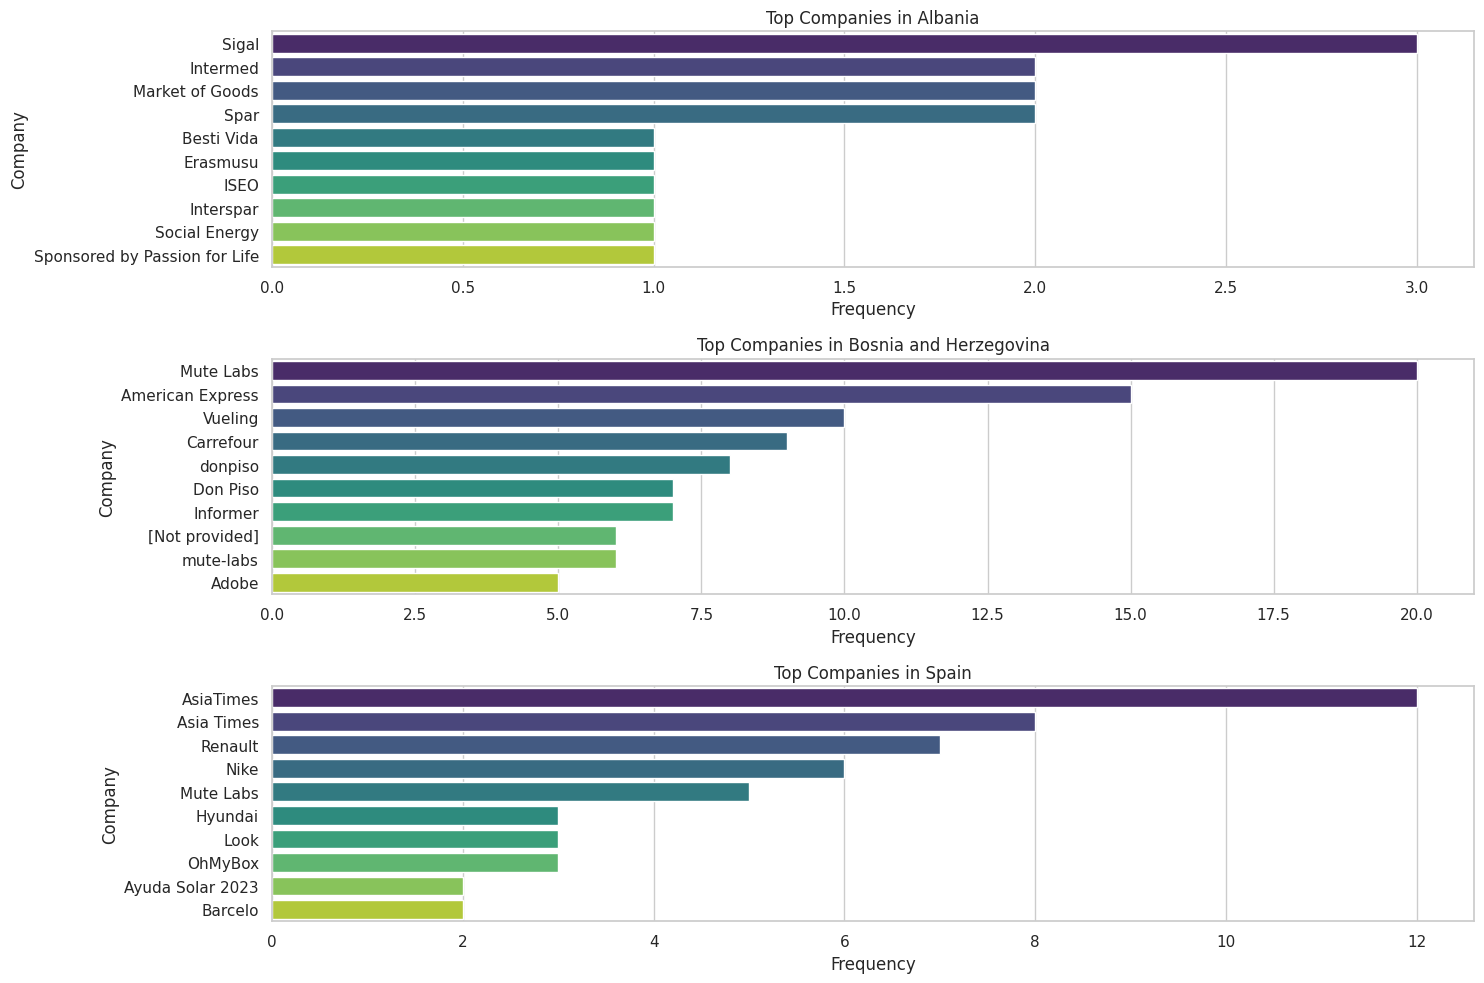

<ipython-input-38-9fbadbcade03>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-38-9fbadbcade03>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-38-9fbadbcade03>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


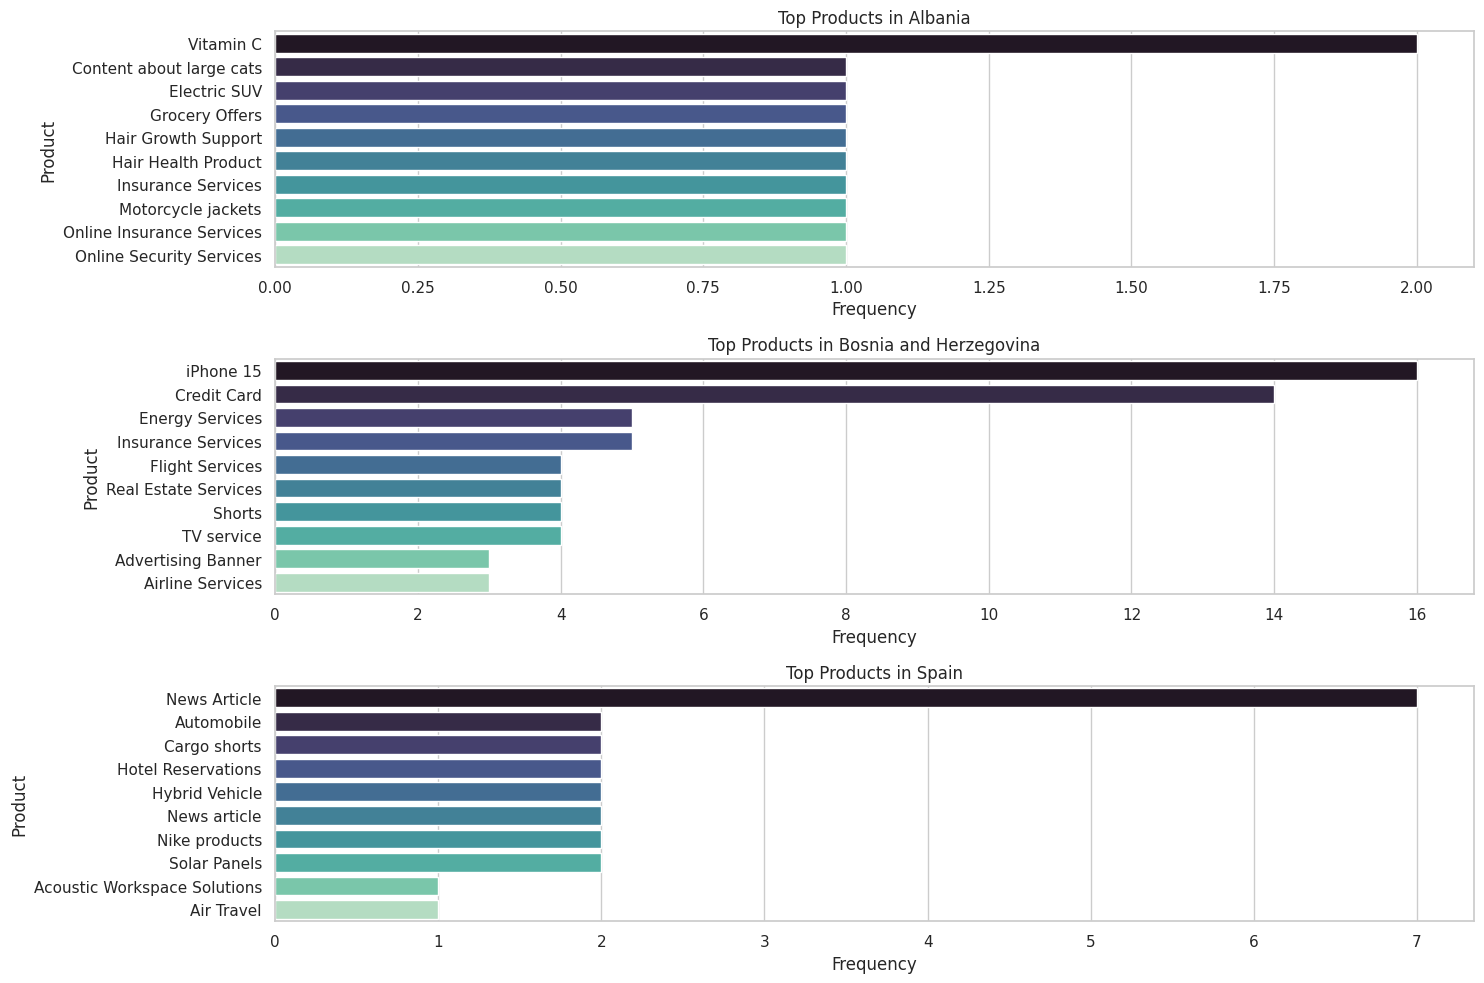

In [39]:
plot_top_companies(merged_data_with_org)
plot_top_products(merged_data_with_org)

### Most Frequent Companies/Products per Country for  dataset with indirect relationship with the EU Elections

<ipython-input-40-266079b06bcc>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-40-266079b06bcc>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-40-266079b06bcc>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


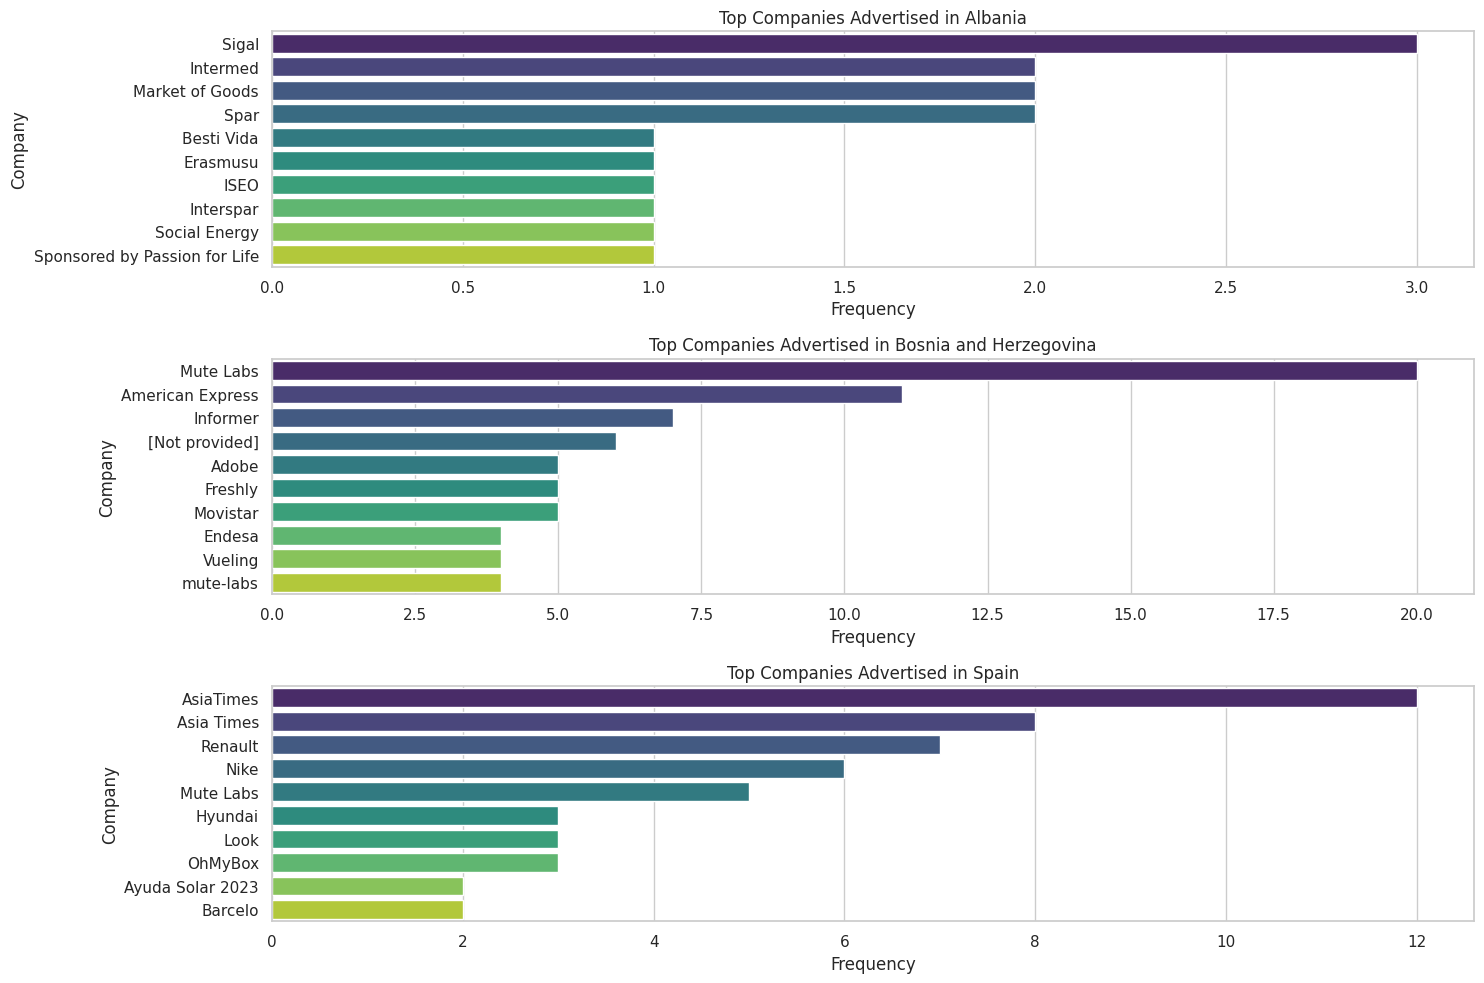

<ipython-input-41-75a4ae162f62>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-41-75a4ae162f62>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
<ipython-input-41-75a4ae162f62>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


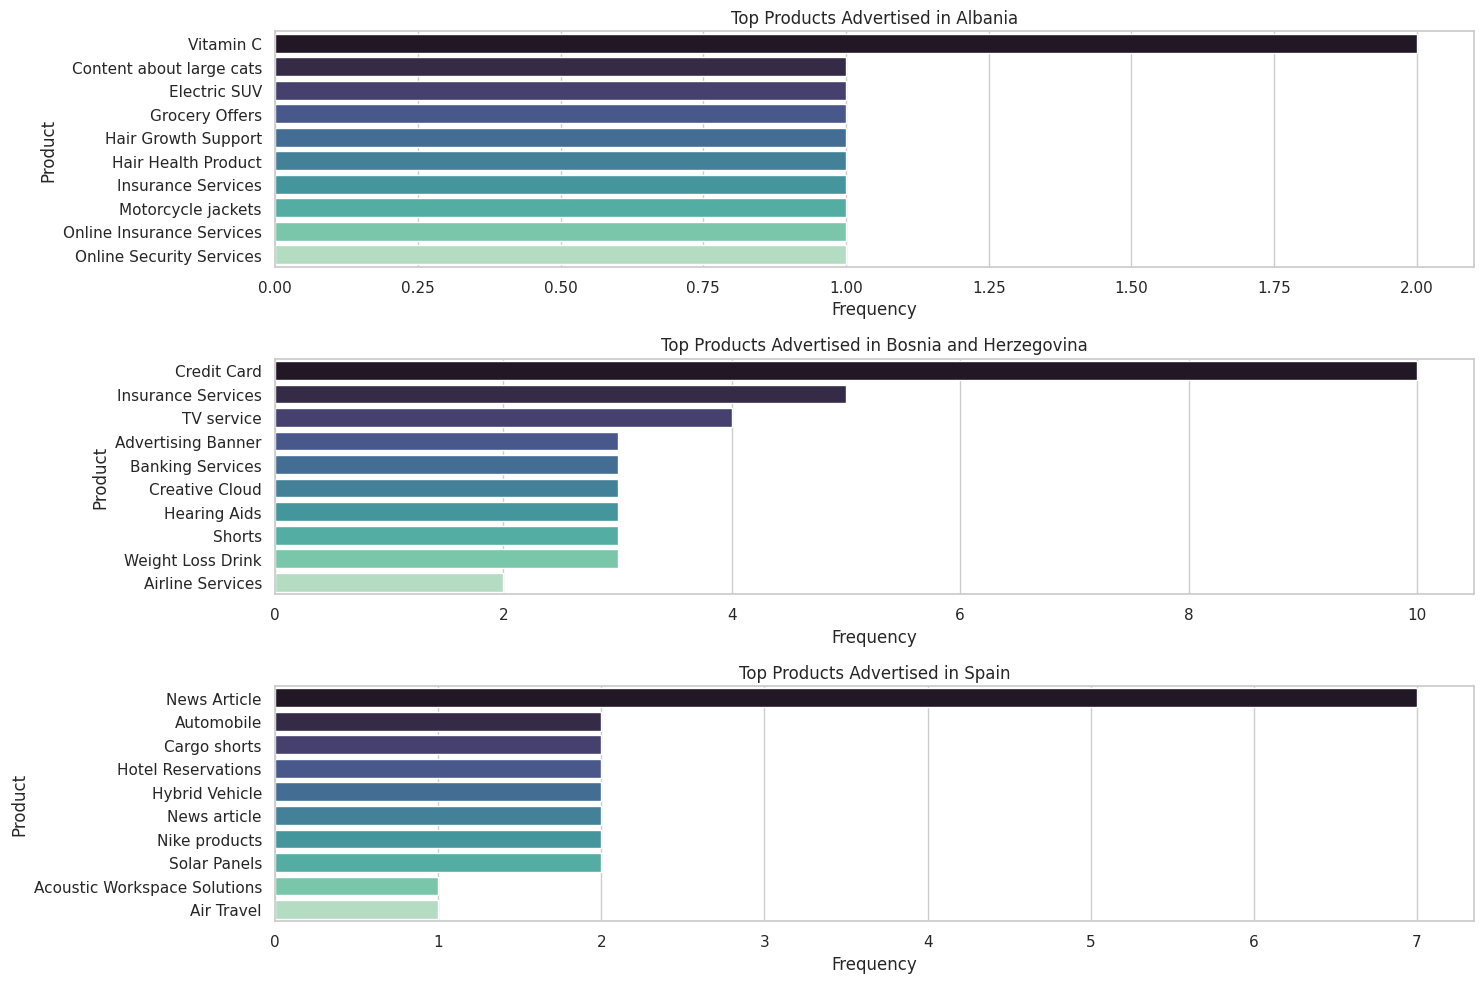

In [43]:
indirect_eurelation = merged_data_with_org[merged_data_with_org['euRelation']== 'Indirect']
plot_top_companies(indirect_eurelation)
plot_top_products(indirect_eurelation)

### Most Frequent Companies/Products per Country for  dataset with indirect relationship with the EU Elections

<ipython-input-40-266079b06bcc>:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


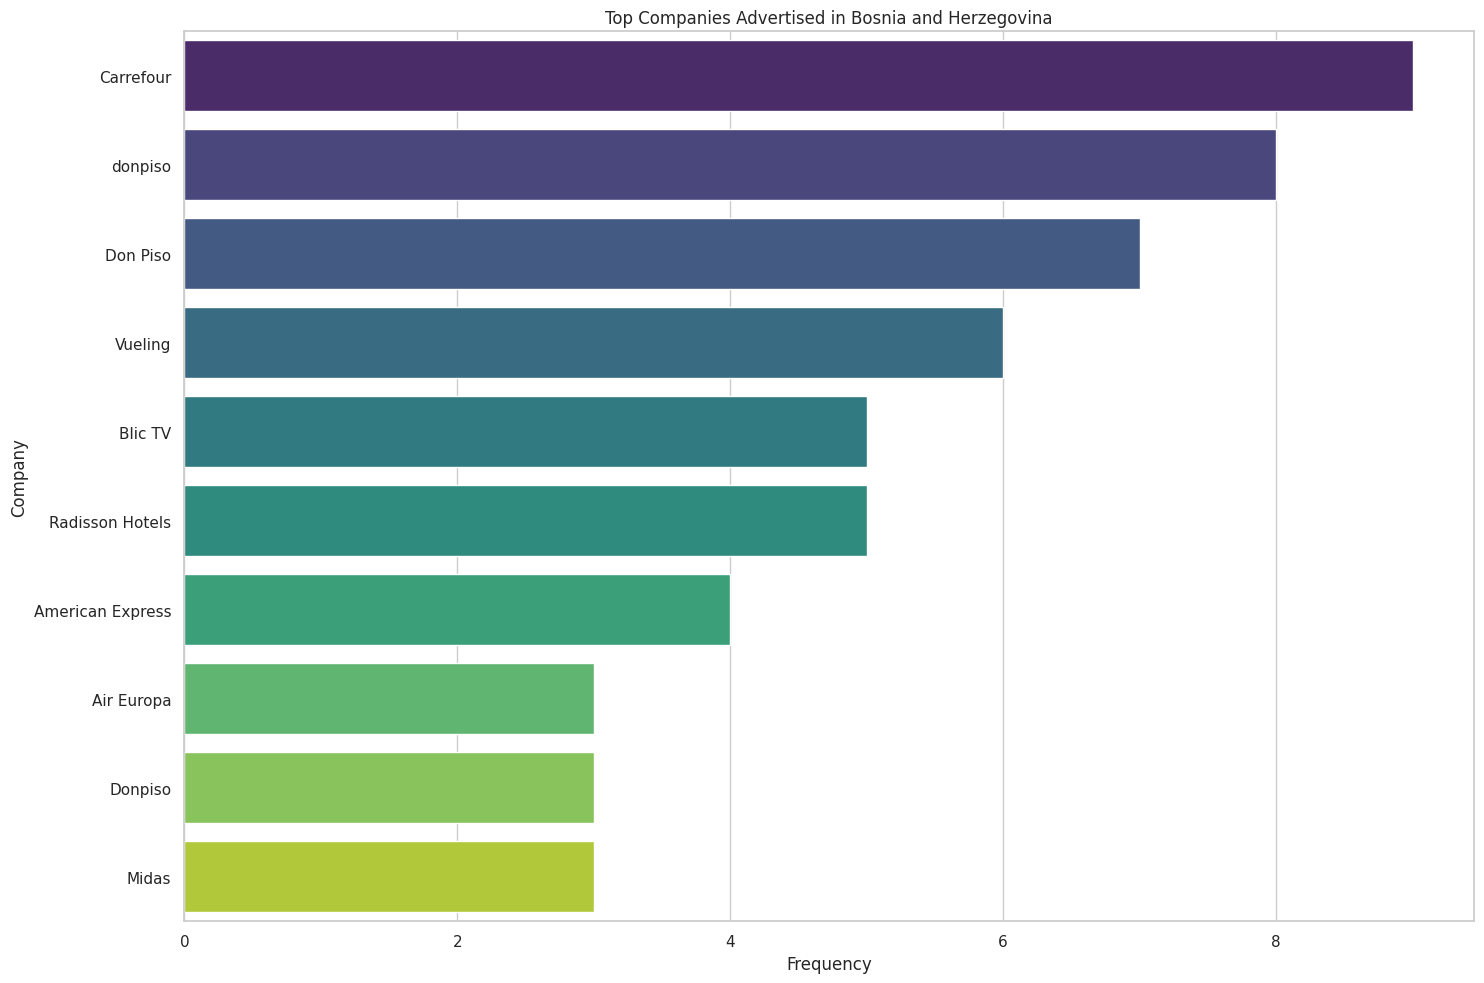

<ipython-input-41-75a4ae162f62>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


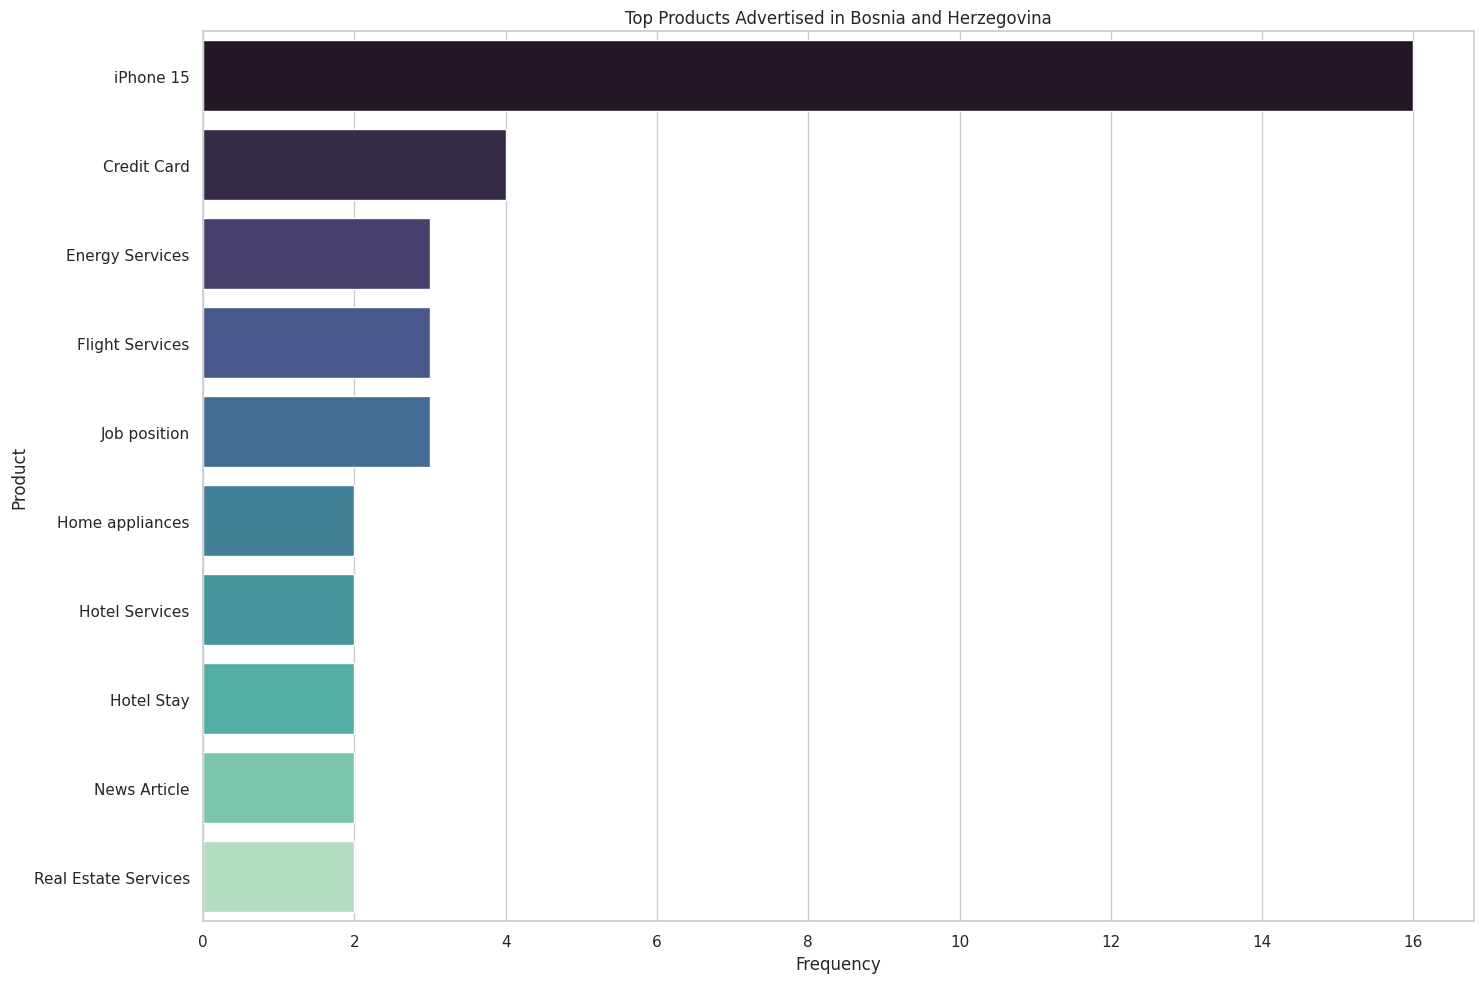

In [44]:
direct_eurelation = merged_data_with_org[merged_data_with_org['euRelation']== 'Direct']
plot_top_companies(direct_eurelation)
plot_top_products(direct_eurelation)

In [8]:
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE

def generate_embeddings(df, column_name, perplexity=30, n_iter=1000):
    """Generate embeddings and reduce dimensionality using t-SNE"""
    # Clean data
    df[column_name] = df[column_name].fillna('')
    mask = df[column_name].str.len() > 0
    clean_data = df[mask]

    # Generate embeddings
    model = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = model.encode(clean_data[column_name].tolist(), show_progress_bar=True)

    # Apply t-SNE
    tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=n_iter, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    # Create DataFrame with embeddings and metadata
    embed_df = pd.DataFrame({
        'x': embeddings_2d[:, 0],
        'y': embeddings_2d[:, 1],
        'text': clean_data[column_name],
        'euRelation': clean_data['euRelation'],
        'countryOfOrigin': clean_data['countryOfOrigin'],
    })

    return embed_df


# Generate embeddings for Products and Companies
product_embeddings = generate_embeddings(merged_data_with_org, 'Product')
company_embeddings = generate_embeddings(merged_data_with_org, 'Company')

/usr/local/lib/python3.10/dist-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/46 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Batches:   0%|          | 0/44 [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [9]:
import plotly.express as px

In [11]:
# Cell 2: Product Embeddings by Country
fig_product_country = px.scatter(
    product_embeddings,
    x='x',
    y='y',
    color='countryOfOrigin',
    title='Products by Country',
    color_discrete_sequence=px.colors.qualitative.Set1,
    hover_data={
        'x': False,
        'y': False,
        'text': True,
        'countryOfOrigin': True
    }
)

fig_product_country.update_layout(
    title={
        'text': 'Products Clustered by Country',
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=24)
    },
    plot_bgcolor='white',
    width=1200,
    height=800,
    showlegend=True,
    legend=dict(
        title=dict(text='Countries', font=dict(size=16)),
        font=dict(size=14),
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02
    )
)

fig_product_country.update_traces(
    marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')),
    opacity=0.7
)

fig_product_country.update_xaxes(title_text='t-SNE Dimension 1', title_font=dict(size=16), showgrid=True, gridwidth=1, gridcolor='LightGray')
fig_product_country.update_yaxes(title_text='t-SNE Dimension 2', title_font=dict(size=16), showgrid=True, gridwidth=1, gridcolor='LightGray')

fig_product_country.show()
# save fig to html
fig_product_country.write_html("product_Country.html")

In [13]:
# Cell 2: Company Embeddings by Country
fig_Company_country = px.scatter(
    company_embeddings,
    x='x',
    y='y',
    color='countryOfOrigin',
    title='Companys by Country',
    color_discrete_sequence=px.colors.qualitative.Set1,
    hover_data={
        'x': False,
        'y': False,
        'text': True,
        'countryOfOrigin': True
    }
)

fig_Company_country.update_layout(
    title={
        'text': 'Companys Clustered by Country',
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=24)
    },
    plot_bgcolor='white',
    width=1200,
    height=800,
    showlegend=True,
    legend=dict(
        title=dict(text='Countries', font=dict(size=16)),
        font=dict(size=14),
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02
    )
)

fig_Company_country.update_traces(
    marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')),
    opacity=0.7
)

fig_Company_country.update_xaxes(title_text='t-SNE Dimension 1', title_font=dict(size=16), showgrid=True, gridwidth=1, gridcolor='LightGray')
fig_Company_country.update_yaxes(title_text='t-SNE Dimension 2', title_font=dict(size=16), showgrid=True, gridwidth=1, gridcolor='LightGray')

fig_Company_country.show()
# save fig to html
fig_Company_country.write_html("company_Country.html")

In [11]:
# Cell 2: Company Embeddings by EU Relation
fig_Company_eurelation = px.scatter(
    company_embeddings,
    x='x',
    y='y',
    color='euRelation',
    title='Companys by EU Relations',
    color_discrete_sequence=px.colors.qualitative.Set1,
    hover_data={
        'x': False,
        'y': False,
        'text': True,
        'euRelation': True
    }
)

fig_Company_eurelation.update_layout(
    title={
        'text': 'Companys Clustered by EU Relation',
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=24)
    },
    plot_bgcolor='white',
    width=1200,
    height=800,
    showlegend=True,
    legend=dict(
        title=dict(text='EU Relation', font=dict(size=16)),
        font=dict(size=14),
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02
    )
)

fig_Company_eurelation.update_traces(
    marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')),
    opacity=0.7
)

fig_Company_eurelation.update_xaxes(title_text='t-SNE Dimension 1', title_font=dict(size=16), showgrid=True, gridwidth=1, gridcolor='LightGray')
fig_Company_eurelation.update_yaxes(title_text='t-SNE Dimension 2', title_font=dict(size=16), showgrid=True, gridwidth=1, gridcolor='LightGray')

fig_Company_eurelation.show()
# save fig to html
fig_Company_eurelation.write_html("company_Country.html")

In [12]:
# Cell 2: Company Embeddings by EU Relation
fig_product_eurelation = px.scatter(
    product_embeddings,
    x='x',
    y='y',
    color='euRelation',
    title='Products by EU Relation',
    color_discrete_sequence=px.colors.qualitative.Set1,
    hover_data={
        'x': False,
        'y': False,
        'text': True,
        'euRelation': True
    }
)

fig_product_eurelation.update_layout(
    title={
        'text': 'Products Clustered by EU Relation',
        'y':0.95,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=24)
    },
    plot_bgcolor='white',
    width=1200,
    height=800,
    showlegend=True,
    legend=dict(
        title=dict(text='EU Relation', font=dict(size=16)),
        font=dict(size=14),
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=1.02
    )
)

fig_product_eurelation.update_traces(
    marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')),
    opacity=0.7
)

fig_product_eurelation.update_xaxes(title_text='t-SNE Dimension 1', title_font=dict(size=16), showgrid=True, gridwidth=1, gridcolor='LightGray')
fig_product_eurelation.update_yaxes(title_text='t-SNE Dimension 2', title_font=dict(size=16), showgrid=True, gridwidth=1, gridcolor='LightGray')

fig_product_eurelation.show()
# save fig to html
fig_product_eurelation.write_html("company_Country.html")